In [1]:
from models import GraspAnalysisResults
from utils import GraspAnalysisUtils
from pathlib import Path
import numpy as np


In [2]:
# Find folder containing CSV files for analysis
data_folder = GraspAnalysisUtils.select_folder()


Selected folder: C:/Users/rjs15/grasp_strength_ws/astm_grasp_strength_analysis/sample_data/robotiq_cylinder


In [3]:
# Check if there as csv files in the chosen directory
dir_path = Path(data_folder)
if any(file.suffix.lower() == ".csv" for file in dir_path.iterdir() if file.is_file()):
    files = [str(file) for file in dir_path.glob("*.csv")]
    print("CSV files located")
else:
    raise RuntimeError("No CSV files found in chosen folder")

CSV files located


In [4]:
# Plot Dialog Selection
chosen_plots = GraspAnalysisUtils.select_desired_plots()
print(f"User wants to create: {chosen_plots}")

User wants to create: ['Raw Data Plot', 'Scatter Plot of Forces', 'Rolling Mean Plot', 'Rolling Standard Deviation Plot', 'Rolling Median Plot', 'Box Plot']


In [5]:
# Assignment of variables
SAMPLE_SIZE = 200
OFFSET = 2000
MIN_FORCE_THRESHOLD = 10

Filename: RobotIQ_60SFMA_50Cycles_Cyl.csv

Number of grasps detected: 50

The average strength of a grasp is 206.51 N
95% confidence interval: [(205.26, 207.76)]
The standard deviation for grasp strength is 4.41 N
95% Confidence interval for standard deviation: [3.68, 5.49]
Recommended number of samples to collect: 13




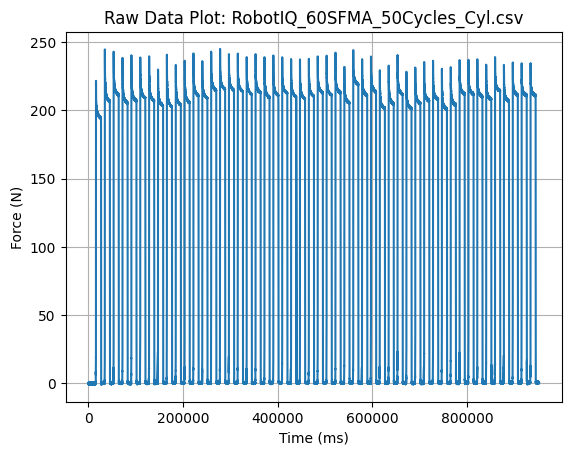

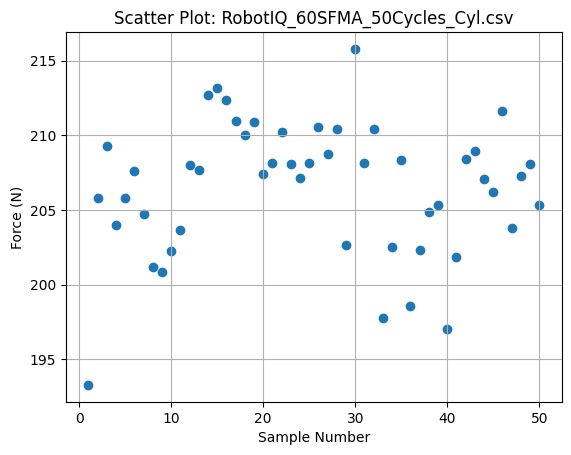

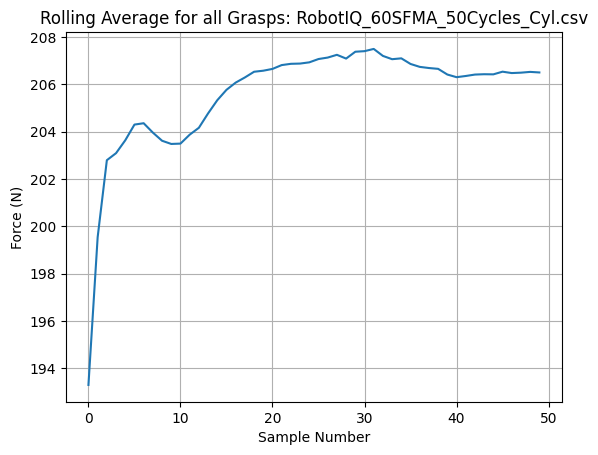

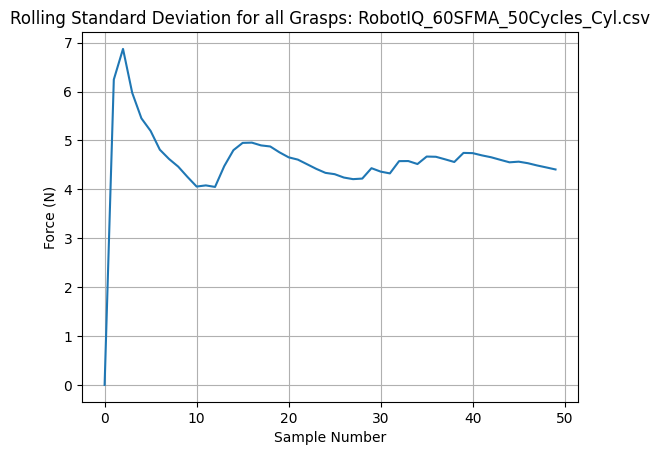

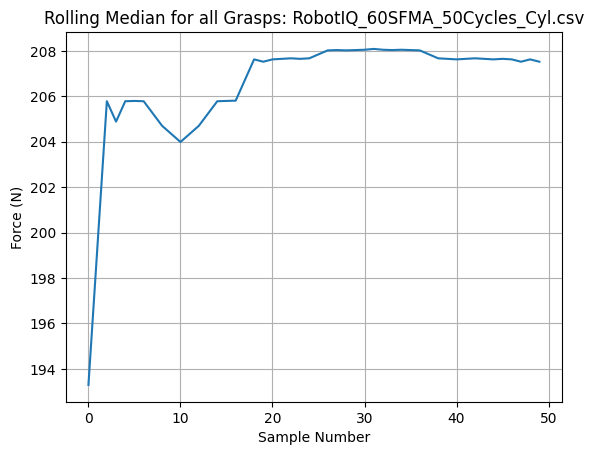

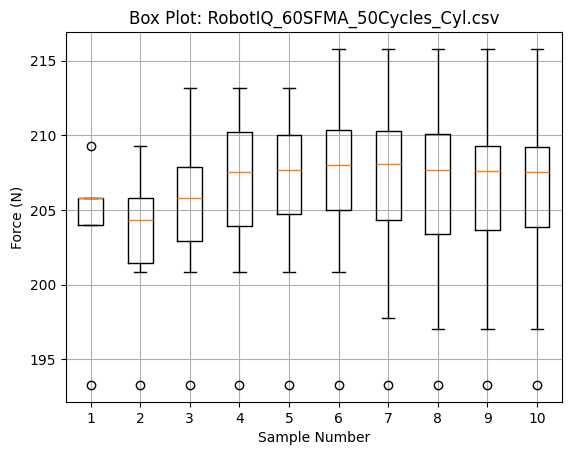

In [ ]:
# Performing Analysis

for file_path in files:
    
    filename = Path(file_path).name

    force_data = GraspAnalysisUtils.load_and_preprocess_data(file_path)

    grasps = GraspAnalysisUtils.detect_grasp_regions(force_data, SAMPLE_SIZE, MIN_FORCE_THRESHOLD)

    number_of_grasps = len(grasps)

    cumulative_avg = []
    cumulative_std = []
    cumulative_median = []

    if number_of_grasps == 0:
        Warning(f"No grasps detected in file: {filename}")
        continue

    avg_forces = []
    for grasp in grasps:
        grasp = GraspAnalysisUtils.calculate_grasp_force(force_data[grasp.start_idx:grasp.end_idx], grasp, OFFSET)

        avg_forces.append(grasp.avg_force)
        cumulative_avg.append(np.mean(avg_forces))
        cumulative_std.append(np.std(avg_forces))
        cumulative_median.append(np.median(avg_forces))

    # Calculate Statistics 
    mean, std, sem, ts, ci, pi, cv_percent = GraspAnalysisUtils.calculate_grasp_statistics(number_of_grasps, grasps)

    required_samples = GraspAnalysisUtils.calculate_required_samples(mean, std, number_of_grasps)
    
    if required_samples is not None:
        moe, n_required, n_required_buffer, std_dev_interval_lwr, std_dev_interval_upr, n_required_std = required_samples
        
    result = GraspAnalysisResults(
        filename,
        number_of_grasps,
        mean,
        std,
        sem,
        ts,
        ci,
        pi,
        cv_percent,
        cumulative_avg,
        cumulative_std,
        cumulative_median,
        n_required,
        n_required_buffer,
        moe,
        std_dev_interval_lwr,
        std_dev_interval_upr,
        n_required_std
    )

    GraspAnalysisUtils.report_results(result)

    GraspAnalysisUtils.create_grasp_plots(chosen_plots, force_data, result, grasps)